# 14. Classification III: Kernels and Decision Trees
@Shengli (Bruce) Jiang, University of South Carolina

## What We Have Covered

- Python, NumPy, pandas, functions, and plotting
- Regression, regularization, and hyperparameter tuning
- Scaling, feature engineering, categorical encoding, and missing values
- Logistic regression, probabilities, and classification metrics
- Linear support vector machines, margins, support vectors, and the parameter `C`

## What We Covered in the Last Lecture

A linear SVM chooses a decision boundary with a wide margin. Only the support vectors directly determine that boundary.

- A small `C` allows more margin violations and gives stronger regularization.
- A large `C` penalizes violations more strongly.
- Scaling belongs inside the pipeline because SVM depends on distances and dot products.

Today we allow nonlinear boundaries and then introduce a different type of classifier: the decision tree.

## Today's Learning Objectives

By the end of this notebook, you should be able to:

1. Explain how a feature map can make nonlinear data linearly separable.
2. Explain how a kernel computes similarity without building every transformed feature.
3. Describe how polynomial degree and RBF `gamma` change model flexibility.
4. Compare linear, polynomial, and RBF SVM kernels with cross-validation.
5. Calculate Gini impurity and compare candidate tree splits.
6. Fit a decision tree and read its rules as text.

## Running the Notebook

All datasets are included with scikit-learn, so no download is required. Run the cells from top to bottom.

The decision tree is printed as text with `export_text`. We will not draw the tree.

In [1]:
%matplotlib inline

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from IPython.display import display

## 1. From a Nonlinear Pattern to a Linear Split

The two classes below form an inner circle and an outer circle. No straight line can separate them in the original two-dimensional space.

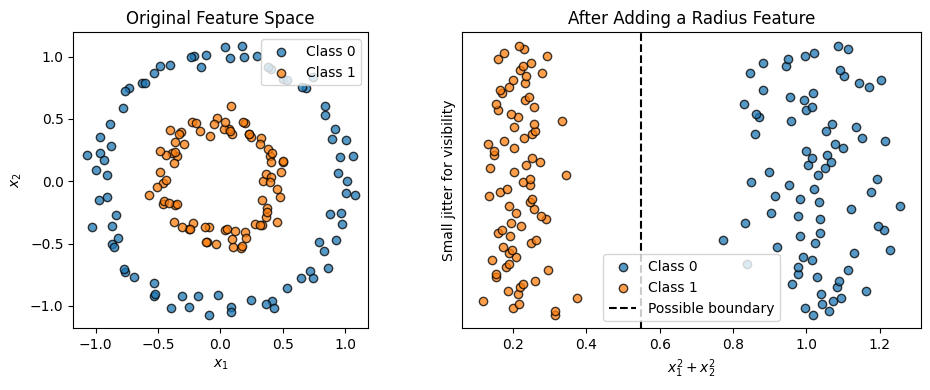

In [2]:
from sklearn.datasets import make_circles

X_circle, y_circle = make_circles(
    n_samples=160, factor=0.45, noise=0.06, random_state=26
)

radius_squared = X_circle[:, 0] ** 2 + X_circle[:, 1] ** 2

fig, ax = plt.subplots(1, 2, figsize=(10, 4))

for label, color in [(0, "C0"), (1, "C1")]:
    selected = y_circle == label
    ax[0].scatter(
        X_circle[selected, 0], X_circle[selected, 1],
        color=color, edgecolor="black", alpha=0.75, label=f"Class {label}"
    )

    jitter = np.linspace(-0.04, 0.04, selected.sum())
    ax[1].scatter(
        radius_squared[selected], jitter,
        color=color, edgecolor="black", alpha=0.75, label=f"Class {label}"
    )

ax[0].set(xlabel=r"$x_1$", ylabel=r"$x_2$", title="Original Feature Space")
ax[0].set_aspect("equal")
ax[0].legend()

ax[1].axvline(0.55, color="black", linestyle="--", label="Possible boundary")
ax[1].set(
    xlabel=r"$x_1^2+x_2^2$", ylabel="Small jitter for visibility",
    title="After Adding a Radius Feature", yticks=[]
)
ax[1].legend()

fig.tight_layout()
plt.show()

The new feature

$$
r^2=x_1^2+x_2^2
$$

turns the circular pattern into a one-dimensional threshold problem. The boundary is linear in the transformed feature, even though it is curved in the original space.

## 2. The Polynomial Kernel

For a degree-two transformation, define

$$
\phi(\mathbf{x})=
\begin{bmatrix}
x_1^2 & \sqrt{2}x_1x_2 & x_2^2
\end{bmatrix}^{T}.
$$

The dot product in this transformed space has a shortcut:

$$
\phi(\mathbf{x})^T\phi(\mathbf{z})=(\mathbf{x}^T\mathbf{z})^2.
$$

In [3]:
x = np.array([1.0, 2.0])
z = np.array([3.0, 1.0])

phi_x = np.array([x[0] ** 2, np.sqrt(2) * x[0] * x[1], x[1] ** 2])
phi_z = np.array([z[0] ** 2, np.sqrt(2) * z[0] * z[1], z[1] ** 2])

explicit_dot_product = phi_x @ phi_z
kernel_value = (x @ z) ** 2

print("Dot product after explicit mapping:", explicit_dot_product)
print("Polynomial kernel value:", kernel_value)

Dot product after explicit mapping: 25.000000000000004
Polynomial kernel value: 25.0


Both calculations give the same value. The **kernel trick** evaluates the dot product in the transformed feature space without explicitly constructing all transformed features.

For scikit-learn's polynomial kernel,

$$
K(\mathbf{x},\mathbf{z})=(\gamma\mathbf{x}^T\mathbf{z}+c_0)^d.
$$

The degree $d$ controls which polynomial interactions are available.

## 3. The RBF Kernel

The radial basis function kernel measures similarity from the distance between two samples:

$$
K(\mathbf{x},\mathbf{z})=\exp\left(-\gamma\lVert\mathbf{x}-\mathbf{z}\rVert^2\right).
$$

Nearby points have similarity close to 1. Distant points have similarity close to 0.

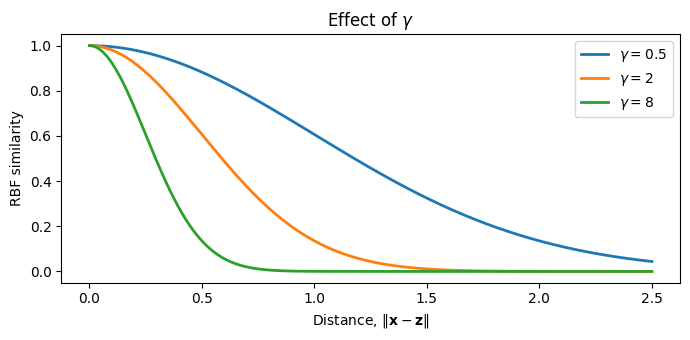

In [4]:
distance = np.linspace(0, 2.5, 300)
gammas = [0.5, 2, 8]

fig, ax = plt.subplots(figsize=(7, 3.5))

for gamma, color in zip(gammas, ["C0", "C1", "C2"]):
    similarity = np.exp(-gamma * distance ** 2)
    ax.plot(distance, similarity, color=color, linewidth=2, label=fr"$\gamma={gamma}$")

ax.set(
    xlabel=r"Distance, $\Vert\mathbf{x}-\mathbf{z}\Vert$",
    ylabel="RBF similarity", title=r"Effect of $\gamma$"
)
ax.legend()

fig.tight_layout()
plt.show()

- Small `gamma`: each sample has broad influence, so the boundary is smoother.
- Large `gamma`: each sample has local influence, so the boundary can become more flexible.

Large `gamma` is not automatically better. It can fit noise and overfit the training data.

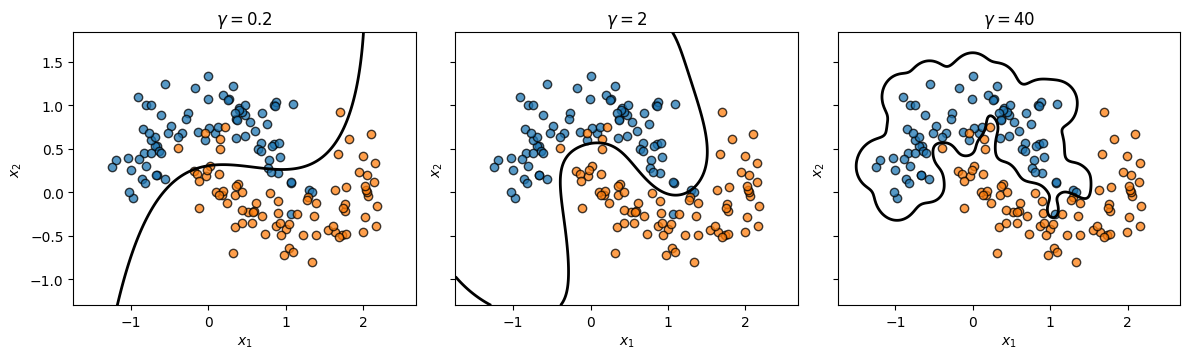

In [5]:
from sklearn.datasets import make_moons
from sklearn.svm import SVC

X_moon, y_moon = make_moons(n_samples=160, noise=0.22, random_state=26)

x1 = np.linspace(X_moon[:, 0].min() - 0.5, X_moon[:, 0].max() + 0.5, 300)
x2 = np.linspace(X_moon[:, 1].min() - 0.5, X_moon[:, 1].max() + 0.5, 300)
xx, yy = np.meshgrid(x1, x2)
grid = np.c_[xx.ravel(), yy.ravel()]

fig, ax = plt.subplots(1, 3, figsize=(12, 3.7), sharex=True, sharey=True)

for axis, gamma in zip(ax, [0.2, 2, 40]):
    model = SVC(kernel="rbf", C=5, gamma=gamma)
    model.fit(X_moon, y_moon)
    decision = model.decision_function(grid).reshape(xx.shape)

    for label, color in [(0, "C0"), (1, "C1")]:
        selected = y_moon == label
        axis.scatter(
            X_moon[selected, 0], X_moon[selected, 1],
            color=color, edgecolor="black", alpha=0.75
        )

    axis.contour(xx, yy, decision, levels=[0], colors="black", linewidths=2)
    axis.set(xlabel=r"$x_1$", ylabel=r"$x_2$", title=fr"$\gamma={gamma}$")

fig.tight_layout()
plt.show()

## 4. Case Study: Breast Cancer Classification

The scikit-learn dataset contains 569 samples and 30 measured cell-nucleus features. The target is malignant or benign.

We will compare linear, polynomial, and RBF SVM kernels. The test set remains untouched until the final model is selected.

In [6]:
from sklearn.datasets import load_breast_cancer

cancer = load_breast_cancer(as_frame=True)
X = cancer.data
y = cancer.target

summary = pd.DataFrame({
    "Samples": [X.shape[0]],
    "Features": [X.shape[1]],
    "Classes": [", ".join(cancer.target_names)]
})

display(summary)
display(X.head())

,Samples,Features,Classes
0,569,30,"malignant, benign"


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


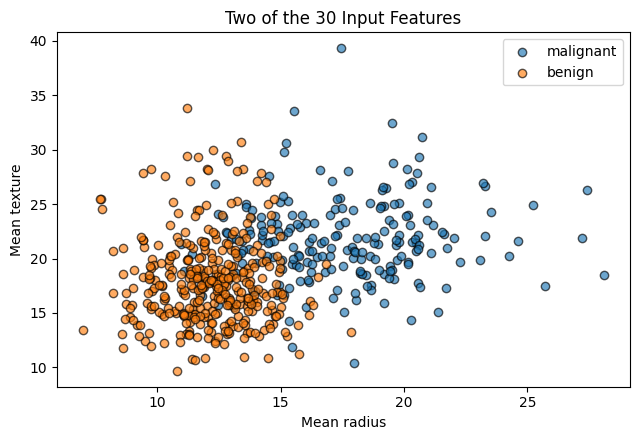

In [7]:
fig, ax = plt.subplots(figsize=(6.5, 4.5))

for label, color in [(0, "C0"), (1, "C1")]:
    selected = y == label
    ax.scatter(
        X.loc[selected, "mean radius"], X.loc[selected, "mean texture"],
        color=color, edgecolor="black", alpha=0.65,
        label=cancer.target_names[label]
    )

ax.set(
    xlabel="Mean radius", ylabel="Mean texture",
    title="Two of the 30 Input Features"
)
ax.legend()

fig.tight_layout()
plt.show()

The two classes overlap in this plot. The classifier will use all 30 features, not only the two shown here.

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=26
)

svm_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC())
])

print("Training samples:", len(X_train))
print("Test samples:", len(X_test))

Training samples: 455
Test samples: 114


Scaling is fitted inside each cross-validation training fold because SVM depends on distances and dot products.

Different kernels need different hyperparameters:

- Linear: `C`
- Polynomial: `C` and `degree`
- RBF: `C` and `gamma`

In [9]:
from sklearn.model_selection import GridSearchCV

param_grid = [
    {"svm__kernel": ["linear"], "svm__C": [0.1, 1, 10]},
    {"svm__kernel": ["poly"], "svm__C": [0.1, 1, 10], "svm__degree": [2, 3, 4]},
    {"svm__kernel": ["rbf"], "svm__C": [0.1, 1, 10],
     "svm__gamma": [0.001, 0.01, 0.1, 1]}
]

search = GridSearchCV(
    svm_pipeline, param_grid, cv=5, scoring="accuracy", return_train_score=True
)
search.fit(X_train, y_train)

print("Best CV accuracy:", round(search.best_score_, 3))
print("Best parameters:", search.best_params_)

Best CV accuracy: 0.969
Best parameters: {'svm__C': 10, 'svm__kernel': 'linear'}


In [10]:
cv_results = pd.DataFrame(search.cv_results_)

best_by_kernel = (
    cv_results.groupby("param_svm__kernel")["mean_test_score"]
    .max()
    .sort_values(ascending=False)
    .rename("Best CV accuracy")
)

display(best_by_kernel.to_frame().round(3))

,Best CV accuracy
param_svm__kernel,
linear,0.969
rbf,0.960
poly,0.945


Cross-validation chooses the kernel and its hyperparameters using only the training data. A nonlinear kernel is useful only when it improves validation performance.

In [11]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_svm_pred = search.predict(X_test)

print("Test accuracy:", round(accuracy_score(y_test, y_svm_pred), 3))
print()
print(classification_report(y_test, y_svm_pred, target_names=cancer.target_names))

svm_confusion = pd.DataFrame(
    confusion_matrix(y_test, y_svm_pred),
    index=[f"Actual {name}" for name in cancer.target_names],
    columns=[f"Predicted {name}" for name in cancer.target_names]
)
display(svm_confusion)

Test accuracy: 0.982

              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



,Predicted malignant,Predicted benign
Actual malignant,41,1
Actual benign,1,71


## 5. Decision Trees

A decision tree repeatedly applies simple if-then rules. Each split sends samples to two child nodes.

For classification, a good split creates child nodes that contain cleaner class groups.

### Gini Impurity

For class proportions $p_1, p_2, \ldots, p_k$,

$$
G=1-\sum_{j=1}^{k}p_j^2.
$$

- A pure node has $G=0$.
- A 50/50 binary node has $G=0.5$.
- Lower impurity means cleaner class separation.

In [12]:
split_counts = pd.DataFrame({
    "Candidate": ["Pressure", "Pressure", "Temperature", "Temperature"],
    "Child": ["Left", "Right", "Left", "Right"],
    "Reaction": [6, 3, 3, 6],
    "No reaction": [2, 3, 4, 1]
})

display(split_counts)

,Candidate,Child,Reaction,No reaction
0,Pressure,Left,6,2
1,Pressure,Right,3,3
2,Temperature,Left,3,4
3,Temperature,Right,6,1


In [13]:
def gini(counts):
    counts = np.asarray(counts)
    proportions = counts / counts.sum()
    return 1 - np.sum(proportions ** 2)


split_results = []

for candidate in ["Pressure", "Temperature"]:
    rows = split_counts[split_counts["Candidate"] == candidate]
    child_sizes = rows[["Reaction", "No reaction"]].sum(axis=1).to_numpy()
    child_gini = rows[["Reaction", "No reaction"]].apply(gini, axis=1).to_numpy()
    weighted_gini = np.sum(child_sizes / child_sizes.sum() * child_gini)
    split_results.append({"Candidate": candidate, "Weighted Gini": weighted_gini})

display(pd.DataFrame(split_results).round(3))

,Candidate,Weighted Gini
0,Pressure,0.429
1,Temperature,0.367


The temperature split has the lower weighted Gini impurity, so it is the better split for these candidate counts.

A tree tests many features and thresholds and keeps the split with the largest impurity reduction.